<a href="https://colab.research.google.com/github/Daudi232/MSc_Data_Science/blob/main/ML_self_learning/pytorch_lightning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CHAPTER 1

## Notes
- Reduces boiler-plate, increases reproducibility and scalability

The key components of lightning are:
- LightningModule: core logic
- Lightning Trainer: supervises the training
- DataModule: organizes data pipelines
- Callbacks: automates events such as checkpointing, early stopping, etc
- Logger: tracks experiments

The lighting module consists of 3 methods:
- init
- forward
- training_step

The trainer looks just like normal training
- initialize the model
- initialize the trainer
- fit the model to data

In [ ]:
!pip install lightning

## Lightning Module

In [ ]:
from lightning.pytorch import LightningModule
from lightning.pytorch import Trainer

import torch.nn as nn
from torch.nn.functional import cross_entropy

import torch.optim as optim


class LightClassifier(LightningModule):

  def __init__(self, inp, num_classes):
    super().__init__()

    self.inp = inp
    self.num_classes = num_classes

    self.layers = nn.Sequential(
        nn.Linear (self.inp, 128),
        nn.Linear(128, self.num_classes)
    )

  def forward(self, x):

    x = x.view(x.shape[0], -1)
    x = self.layers(x)

    return x

  def training_step(self, batch, batch_idx): #maybe batch_idx is used for logging

    x, y = batch

    y_pred = self(x)

    loss = cross_entropy(y_pred, y)
    self.log('train_loss', loss)

    return loss


  def configure_optimizers(self):

    optimizer = optim.Adam(self.parameters(), lr = 1e-3)

    return optimizer

## Data

In [ ]:
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split
from torchvision import transforms as T

transforms = T.Compose ([
    T.ToTensor()
])

train_val_td = MNIST(root = './data', train = True, download=True, transform = transforms)

# split into train and val
train_td, val_td = random_split(train_val_td, lengths = [50000, 10000])

test_td = MNIST(root = './data', train = False, download = True, transform = transforms)

train_dl = DataLoader(train_td, batch_size = 64, shuffle = True)
val_dl = DataLoader(val_td, batch_size = 64)
test_dl = DataLoader(test_td, batch_size = 64)

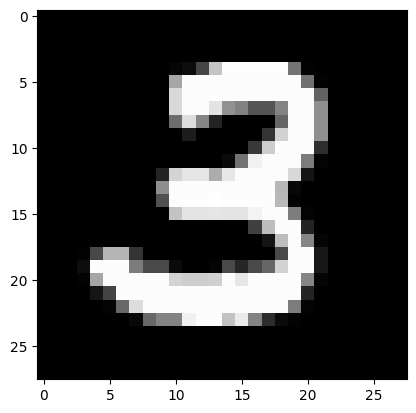

In [ ]:
import matplotlib.pyplot as plt

# i thought this was a pytorch tensor. turns out it is a PIL image already, so this was unnecessary
plt.imshow(train_td[0][0], cmap = 'gray');

In [ ]:
train_td[0][0]

In [ ]:
type(train_td[0][0])

PIL.Image.Image

In [ ]:
# after transforms

type(train_td[0][0])

torch.Tensor

In [ ]:
train_td[0][0].shape

torch.Size([1, 28, 28])

In [ ]:
len(train_td)

50000

In [ ]:
len(val_td)

10000

In [ ]:
len(test_td)

10000

## Training

In [ ]:
from lightning.pytorch import seed_everything

seed_everything(7, workers =True) #sets seeds for reproducibility

model = LightClassifier (28*28, num_classes = 10)

trainer = Trainer(deterministic = True, max_epochs = 3) #deterministic because of the seed

trainer.fit (model, train_dl, val_dl)
# trainer.validate (model, val_dl)
# trainer.test()

INFO: Seed set to 7
INFO:lightning.fabric.utilities.seed:Seed set to 7
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatica

┏━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name   ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layers │ Sequential │ 50.9 K │ train │     0 │
└───┴────────┴────────────┴────────┴───────┴───────┘

Trainable params: 50.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 50.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1792x28 and 784x64)

# CHAPTER 2: MANAGING DATA WITH LIGHTNING MODULE

In this chapter, we will look at the data module, call-backs and connect everything together for training.

## Notes

In the data module, we have a number of methods:
- prepare_data: downloading data (not sure)
- setup: splitting the data. stage depends with the trainer
- dataloaders: explicitly defining dataloaders within the data pipeline to avoid cluters

## Next steps

- Log metrics using CSVLogger and TensorBoard (Weights and Biases is also a nice tool. We will see if time will allow to try it out)
- Perform Inferencing
- Organize the notebook such that it can be made public
- Attempt quizzes to complete the course
- Use pl in my research!

## Installs and Imports

In [ ]:
!pip install lightning
!pip install torchmetrics

In [ ]:
import lightning.pytorch as pl

from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split
from torchvision import transforms as T

import lightning.pytorch as pl

import torch
import torch.nn as nn
from torch.nn.functional import cross_entropy

import torch.optim as optim

from torchmetrics import Accuracy

from lightning.pytorch.callbacks import Callback, ModelCheckpoint, EarlyStopping, RichProgressBar

import pandas as pd
import matplotlib.pyplot as plt
import PIL

## Data Module

In [ ]:
class MNISTData(pl.LightningDataModule):

  def __init__(self, data_dir = './data', batch_size = 64):
    super().__init__()

    self.data_dir = data_dir
    self.batch_size = batch_size
    self.transforms = T.ToTensor()

  def prepare_data(self):
    MNIST(root = self.data_dir, train = True, download = True)

  def setup (self, stage = None):
    dataset = MNIST(root = self.data_dir, train = True, transform = self.transforms)

    if stage == 'fit' or stage is None:
      # split data
      self.train_td, self.val_td = random_split (dataset, lengths = [50000, 10000])

    if stage == 'test' or stage is None:
      self.test_td = MNIST(root = self.data_dir, train = False, transform = self.transforms)

  def train_dataloader(self):
    return DataLoader (self.train_td, batch_size = self.batch_size, shuffle = True)

  def val_dataloader(self):
    return DataLoader (self.val_td, batch_size = self.batch_size)

  def test_dataloader(self):
    return DataLoader (self.test_td, batch_size = self.batch_size)

## Lighting Module

In [ ]:
# we were experimenting with what to use for flattening in the forward function
# goal was to ensure that batches are maintained, and every other dim is flattened
# view is the best option

import torch
t = torch.rand((10, 1, 3, 3))
print(t.shape)
t = t.flatten()
print(t.shape)

v = torch.rand((10, 1, 3, 3))
print(v.shape)
k = v.view(-1, 3*3)
print(v.shape) #shape of v does not change
print(k.shape) # shape of k has changed. this means k is a separate copy in memory

# Gemini's idea was to grab the batch size and flatten the rest dynamically
b_size, ch, h, w = v.shape
print(b_size, ch, h, w)

torch.Size([10, 1, 3, 3])
torch.Size([90])
torch.Size([10, 1, 3, 3])
torch.Size([10, 1, 3, 3])
torch.Size([10, 9])
10 1 3 3


In [ ]:
class LightClassifier(pl.LightningModule):

  def __init__(self, inp, num_classes=10):
    super().__init__()

    self.inp = inp
    self.num_classes = num_classes

    # this line is critical so that loading the model does not require specifying required parameters
    self.save_hyperparameters()

    self.layers = nn.Sequential(
        nn.Linear (self.inp, 128),
        nn.ReLU(),
        nn.Linear(128, self.num_classes)
        #no need of using softmax when using cross_entropy_loss
    )

    self.accuracy = Accuracy(task = 'multiclass', num_classes = num_classes)

  def forward(self, x):

    # initial implementation. would have worked, but gemini had a more cleaner one
    # x = x.view(-1, self.inp)

    b_s, c, h, w = x.shape #only batch size is relevant here

    x = x.view(b_s, -1)
    x = self.layers(x)

    return x

  def training_step(self, batch, batch_idx): #maybe batch_idx is used for logging

    x, y = batch
    y_pred = self(x)

    loss = cross_entropy(y_pred, y)
    self.log('train_loss', loss, on_step = False, on_epoch = True)
    # if we used True, True, the name would have changed to train_loss_epoch for the epoch metrics. #gemini

    acc = self.accuracy(y_pred, y)
    self.log('train_acc', acc, on_step = False, on_epoch = True)

    return loss

  def validation_step(self, batch, batch_idx):

    x, y = batch
    y_pred = self(x)

    # default behavior in validation step is exactly what I desire

    loss = cross_entropy(y_pred, y)
    self.log('val_loss', loss) #by default, on_step = F, on_epoch = T, so we are good

    acc = self.accuracy(y_pred, y)
    self.log('val_acc', acc)

  def test_step(self, batch, batch_idx):

    x, y = batch
    y_pred = self(x)

    loss = cross_entropy(y_pred, y)
    self.log('test_loss', loss)

    acc = self.accuracy(y_pred, y)
    self.log('test_acc', acc)

  def configure_optimizers(self):

    optimizer = optim.Adam(self.parameters(), lr = 1e-3)

    return optimizer

## Call backs

In [ ]:
save_path = './models'

checkpoint = ModelCheckpoint(
    monitor = 'val_loss',
    dirpath = save_path,
    filename = '{epoch}-{val_loss:.2f}',
    save_top_k = 1,
    mode = 'min'
)

es = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    mode = 'min'
)

# Custom Callback

class PrintCallBack(Callback):

  def on_train_start(self, trainer, pl_module):
    print('Training has started!')

  def on_train_end(self, trainer, pl_module):
    print('Training has ended!')

print_cb = PrintCallBack()
rich_cb = RichProgressBar()

callbacks = [checkpoint, es, print_cb, rich_cb]

## Logger

In [ ]:
csv_logger = pl.loggers.CSVLogger(save_dir = './csv_logs', name = 'experiment_1_mnist')
tb_logger = pl.loggers.TensorBoardLogger(save_dir = './tb_logs', name = 'experiment_1_mnist')

# Load the TensorBoard extension
%load_ext tensorboard

# point tb to the directory with logs
%tensorboard --logdir tb_logs/ # by default searches in the cwd. the trailing slash specifies that this is a folder.

## Trainer

In [ ]:
model = LightClassifier(inp = 28*28, num_classes = 10)
dm = MNISTData()

trainer = pl.Trainer(max_epochs = 10, logger = [csv_logger, tb_logger], callbacks = callbacks)
trainer.fit(model, dm)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layers   │ Sequential         │  101 K │ train │     0 │
│ 1 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 101 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 101 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Training has started!

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


Training has ended!

## Visualize

In [ ]:
print(csv_logger.log_dir) #where the metrics file is found

./csv_logs/experiment_1_mnist/version_0


In [ ]:
csv = pd.read_csv(f'{csv_logger.log_dir}/metrics.csv')
display(csv.head())
display(csv.info())

#each epoch has double entries.
#one for recording training metrics, the other for validation metrics.

,epoch,step,train_acc,train_loss,val_acc,val_loss
0,0,781,NaN,NaN,0.9332,0.231450
1,0,781,0.90170,0.366227,NaN,NaN
2,1,1563,NaN,NaN,0.9474,0.173883
3,1,1563,0.95172,0.169229,NaN,NaN
4,2,2345,NaN,NaN,0.9598,0.141211


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   epoch       20 non-null     int64  
 1   step        20 non-null     int64  
 2   train_acc   10 non-null     float64
 3   train_loss  10 non-null     float64
 4   val_acc     10 non-null     float64
 5   val_loss    10 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 1.1 KB


None

In [ ]:
csv.groupby('epoch').mean()['train_loss']

# best way to get the metrics for train and val. #gemini
# putting mean in the end of the line does not change the output

,train_loss
epoch,
0,0.366227
1,0.169229
2,0.119488
3,0.090699
4,0.071701
5,0.056859
6,0.047666
7,0.039212
8,0.032577


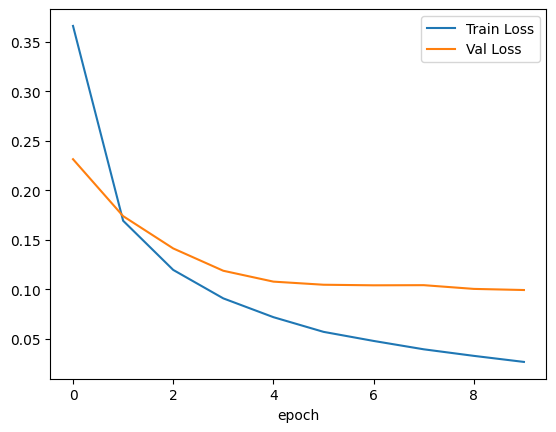

In [ ]:
#train loss
csv.groupby('epoch').mean()['train_loss'].plot(label = 'Train Loss');
csv.groupby('epoch').mean()['val_loss'].plot(label = 'Val Loss');

plt.legend()
plt.show();

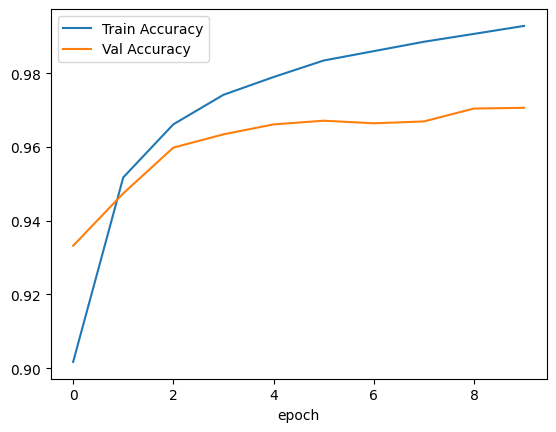

In [ ]:
#train loss
csv.groupby('epoch').mean()['train_acc'].plot(label = 'Train Accuracy');
csv.groupby('epoch').mean()['val_acc'].plot(label = 'Val Accuracy');

plt.legend()
plt.show();

## Test

### straight from trained model

In [ ]:
trainer.test(model, dm)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9765999913215637     │
│         test_loss         │    0.08430449664592743    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.08430449664592743, 'test_acc': 0.9765999913215637}]

In [ ]:
trainer.validate(model, dm)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9706000089645386     │
│         val_loss          │    0.09916061162948608    │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.09916061162948608, 'val_acc': 0.9706000089645386}]

### loading a saved model

- we loaded the lightning module into memory
- we loaded the data module into memory, since we want to use the entire test set

In [ ]:
loaded_model = LightClassifier.load_from_checkpoint('epoch=9-val_loss=0.10.ckpt',
                                                      inp = 28*28,
                                                      num_classes = 10)

# the hyperparameters saving line was not included initially,
# we had to define the required parameters during model loading

trainer = pl.Trainer()
dm = MNISTData()

trainer.test(loaded_model, dm)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9765999913215637     │
│         test_loss         │    0.08430449664592743    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.08430449664592743, 'test_acc': 0.9765999913215637}]

## Inference

5


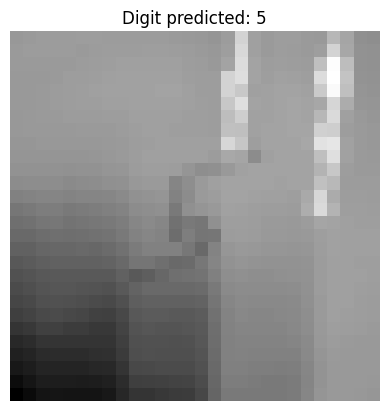

In [ ]:
## Load Image

im = PIL.Image.open('image_5.jpeg').convert('L')
# converts to grayscale, with just 1 color channel

trans = T.Compose([
    T.Resize((28, 28)),
    T.ToTensor()
])

im_trans = trans(im)

# add batch dimension to image
im_trans = im_trans.unsqueeze(0)

# shift image tensor to gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
im_trans = im_trans.to(device)


# Load model for inference
model = LightClassifier.load_from_checkpoint('epoch=9-val_loss=0.10.ckpt',
                                                      inp = 28*28,
                                                      num_classes = 10)

model.to(device)
model.eval()
model.freeze()

## Predict

prediction = model(im_trans)
prediction_class = prediction.argmax(dim = 1).item()
print(prediction_class)

## Visualize

im_disp = im_trans.squeeze(0).cpu()

plt.imshow(im_disp.permute(1, 2, 0), cmap = 'gray')
plt.title(f'Digit predicted: {prediction_class}')
plt.axis('off')
plt.show();

# CHAPTER 3: APPLYING DYNAMIC QUANTIZATION